# DTW-based clustering of solo LTR ratio positional profiles

## Goal

Same pipeline as `dtw_clusters_LTR_identity.ipynb`, but the profile for each
chromosome × family is the **per-bin solo ratio** — defined as:

$$\text{solo ratio} = \frac{\text{solo\_count}}{\text{solo\_count} + \text{intact\_count}}$$

The definition is different than for the rest of the paper (solo ratio = solo count / full-length count), since we need 0-1 bounded values for clustering. The ratio is undefined (NaN) for bins with zero total elements. 

This captures the *spatial pattern of LTR-TE removal intensity* along chromosomes.
High values indicate bins where NAHR-mediated removal is disproportionately active
(or intact elements are depleted); low values indicate retention of intact elements.

Two parallel analyses:
1. **Per-family** — uses `<Family>_solo_count` and `<Family>_intact_count` columns.
2. **All-families pooled** — uses `all_solo_count` and `all_intact_count`.

### Key differences from the LTR identity notebook
- The ratio is computed on the fly from count columns; bins with zero total elements are NaN.
- Filtering is based on the **total element count** per chromosome × family
  (sum of solo + intact across all bins), not just non-NaN bin count.
  This avoids including profiles where the ratio is defined in only a few sparse bins.
- NaN bins (no elements) are imputed with the **chromosome-level mean ratio** before DTW.
- z-score normalisation is applied so DTW compares *shape* of the removal pattern,
  not absolute ratio levels (which vary widely between families and species).
  If you want to cluster on absolute values instead, set `ZSCORE = False`.


In [29]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.stats import chi2_contingency
from dtaidistance import dtw
warnings.filterwarnings('ignore')

In [30]:
from matplotlib import font_manager
import matplotlib

custom_fonts_path = "config/fonts"
custom_fonts = font_manager.findSystemFonts(fontpaths=custom_fonts_path, fontext='ttf')
for font in custom_fonts:
    try:
        font_manager.fontManager.addfont(font)
    except Exception as e:
        print(f"Skipping font {font} due to error: {e}")

matplotlib.rcParams['font.family'] = "sans-serif"
matplotlib.rcParams['font.sans-serif'] = "Arial"

Skipping font /auto/brno12-cerit/nfs4/home/kratka/brno1/LTR-TE_dynamics/config/fonts/fonts/truetype/noto/NotoColorEmoji.ttf due to error: Can not load face (unknown file format; error code 0x2)


## Parameters

In [31]:
# --- EDIT THESE ---
DATA_DIR        = "data/ratio_tables"
OUTPUT_DIR_FAM  = "data/figures/dtw_solo_ratio/per_family"
OUTPUT_DIR_POOL = "data/figures/dtw_solo_ratio/pooled"

# Minimum *total* elements (solo + intact, summed across all bins) for a
# chromosome × family row to be included. Keeps profiles where the ratio
# is estimated from a reasonable number of elements.
MIN_TOTAL_ELEMENTS = 200

# Minimum number of bins that contain at least one element (solo or intact)
# — ensures the profile has spatial spread, not just a handful of populated bins.
MIN_POPULATED_BINS = 30

# Whether to z-score profiles before DTW (recommended: True = compare shape;
# False = compare absolute ratio levels).
ZSCORE = True

SPECIES_METADATA = "data/metadata.tsv"

FAMILIES = ["Ale", "Alesia", "Angela", "Bianca", "Ikeros", "Ivana", "SIRE", "TAR", "Tork",
            "CRM", "Reina", "Tekay", "Athila", "Ogre", "Retand"]

EXCLUDED_SPECIES = ["Chamaelirium_luteum"]

SUPERFAMILY = {
    'Ale': 'Copia', 'Alesia': 'Copia', 'Angela': 'Copia', 'Bianca': 'Copia',
    'Ikeros': 'Copia', 'Ivana': 'Copia', 'SIRE': 'Copia', 'TAR': 'Copia', 'Tork': 'Copia',
    'CRM': 'Gypsy', 'Reina': 'Gypsy', 'Tekay': 'Gypsy',
    'Athila': 'Gypsy', 'Ogre': 'Gypsy', 'Retand': 'Gypsy',
}

os.makedirs(OUTPUT_DIR_FAM,  exist_ok=True)
os.makedirs(OUTPUT_DIR_POOL, exist_ok=True)

In [32]:
metadata_df = pd.read_csv(SPECIES_METADATA, sep='\t')
CENTROMERE_TYPE = dict(zip(metadata_df['Species'], metadata_df['Centromere architecture']))

## Step 1: Build input matrices

In [33]:
def load_bin_data(species, data_dir=DATA_DIR):
    filepath = os.path.join(data_dir, f"{species}_percent_counts.tsv")
    return pd.read_csv(filepath, sep='\t')


def get_species_list(metadata=SPECIES_METADATA):
    metadata_df = pd.read_csv(metadata, sep='\t')
    metadata_df = metadata_df[~metadata_df['Species'].isin(EXCLUDED_SPECIES)]
    return sorted(metadata_df['Species'].unique())


def compute_solo_ratio_profile(solo_vals, intact_vals):
    """Compute per-bin solo ratio, returning NaN where both counts are zero."""
    solo   = np.array(solo_vals,   dtype=float)
    intact = np.array(intact_vals, dtype=float)
    total  = solo + intact
    with np.errstate(invalid='ignore', divide='ignore'):
        ratio = np.where(total > 0, solo / total, np.nan)
    return ratio, total

### Quick column inspection

Run this cell to confirm that `*_solo_count` and `*_intact_count` columns are present
and check the range of the derived solo ratio.

In [34]:
sp0 = get_species_list()[0]
df0 = load_bin_data(sp0)

solo_cols   = [c for c in df0.columns if c.endswith('_solo_count')]
intact_cols = [c for c in df0.columns if c.endswith('_intact_count')]
print(f"Solo count columns in {sp0}:")
for sc in solo_cols:
    ic = sc.replace('_solo_count', '_intact_count')
    if ic in df0.columns:
        ratio, total = compute_solo_ratio_profile(df0[sc], df0[ic])
        valid = np.isfinite(ratio)
        print(f"  {sc:35s}  n_total_elements={int(total.sum()):5.0f}  "
              f"n_populated_bins={valid.sum():4d}  "
              f"mean_ratio={np.nanmean(ratio):.3f}")
    else:
        print(f"  {sc:35s}  (no matching intact column)")

Solo count columns in Bolboschoenus_planiculmis:
  all_solo_count                       n_total_elements= 6104  n_populated_bins=3130  mean_ratio=0.657
  Ivana_solo_count                     n_total_elements= 1382  n_populated_bins= 933  mean_ratio=0.321
  CRM_solo_count                       n_total_elements=  236  n_populated_bins= 225  mean_ratio=0.493
  Athila_solo_count                    n_total_elements=  362  n_populated_bins= 322  mean_ratio=0.638
  Ikeros_solo_count                    n_total_elements= 1665  n_populated_bins=1364  mean_ratio=0.766
  Angela_solo_count                    n_total_elements=  779  n_populated_bins= 661  mean_ratio=0.822
  Ale_solo_count                       n_total_elements=  492  n_populated_bins= 439  mean_ratio=0.431
  Tork_solo_count                      n_total_elements=  751  n_populated_bins= 653  mean_ratio=0.784
  Ogre_solo_count                      n_total_elements=  362  n_populated_bins= 342  mean_ratio=0.889
  Alesia_solo_count     

### 1a. Per-family matrix

Each row = one species × chromosome × family.  
Profile = per-bin solo ratio (NaN where no elements in that bin).  
NaN bins are imputed with the chromosome-level mean ratio before DTW.

In [35]:
species_list = get_species_list()
print(f"Found {len(species_list)} species")

all_profiles_fam = []
all_metadata_fam = []

for sp in species_list:
    df = load_bin_data(sp)
    chr_sizes = df.groupby('chr')['bin_end'].max().to_dict()

    for chrom, df_chr in df.groupby('chr'):
        df_chr = df_chr.sort_values('bin_ID')

        for fam in FAMILIES:
            solo_col   = f"{fam}_solo_count"
            intact_col = f"{fam}_intact_count"
            if solo_col not in df_chr.columns or intact_col not in df_chr.columns:
                continue

            ratio, total = compute_solo_ratio_profile(df_chr[solo_col], df_chr[intact_col])

            total_elements  = int(np.nansum(total))
            populated_bins  = int(np.sum(np.isfinite(ratio)))

            if total_elements < MIN_TOTAL_ELEMENTS or populated_bins < MIN_POPULATED_BINS:
                continue

            # Impute NaN bins with the chromosome-level mean ratio
            row_mean = np.nanmean(ratio)
            ratio_filled = np.where(np.isfinite(ratio), ratio, row_mean)

            if ZSCORE:
                row_std = np.std(ratio_filled)
                if row_std < 1e-4:   # near-flat profile
                    ratio_filled = np.zeros_like(ratio_filled)
                else:
                    ratio_filled = (ratio_filled - row_mean) / row_std

            all_profiles_fam.append(ratio_filled)
            all_metadata_fam.append({
                'species':         sp,
                'chromosome':      chrom,
                'family':          fam,
                'superfamily':     SUPERFAMILY.get(fam, 'unknown'),
                'total_elements':  total_elements,
                'populated_bins':  populated_bins,
                'mean_ratio':      float(row_mean),
                'chr_size':        chr_sizes.get(chrom, np.nan),
                'centromere':      CENTROMERE_TYPE.get(sp, 'unknown'),
            })

V_fam   = np.array(all_profiles_fam)
meta_fam = pd.DataFrame(all_metadata_fam)

print(f"\nPer-family matrix: {V_fam.shape}  (rows = chr × family, columns = positional bins)")
print(f"Holocentric: {(meta_fam['centromere']=='holocentric').sum()}  |  "
      f"Monocentric: {(meta_fam['centromere']=='monocentric').sum()}  |  "
      f"Unknown: {(meta_fam['centromere']=='unknown').sum()}")
print(f"Families represented: {sorted(meta_fam['family'].unique())}")
print(f"\nFamilies with ZERO qualifying rows:")
for fam in FAMILIES:
    if fam not in meta_fam['family'].unique():
        print(f"  {fam}")

print(f"\nMean solo ratio by centromere type (per-family):")
print(meta_fam.groupby('centromere')['mean_ratio'].describe().round(3))

Found 66 species

Per-family matrix: (4329, 97)  (rows = chr × family, columns = positional bins)
Holocentric: 2188  |  Monocentric: 2141  |  Unknown: 0
Families represented: ['Ale', 'Angela', 'Athila', 'Bianca', 'CRM', 'Ikeros', 'Ivana', 'Ogre', 'Reina', 'Retand', 'SIRE', 'TAR', 'Tekay', 'Tork']

Families with ZERO qualifying rows:
  Alesia

Mean solo ratio by centromere type (per-family):
              count   mean    std  min    25%    50%    75%    max
centromere                                                        
holocentric  2188.0  0.767  0.209  0.0  0.662  0.811  0.938  1.000
monocentric  2141.0  0.545  0.222  0.0  0.399  0.580  0.710  0.975


### 1b. Pooled matrix 

Each row = one species × chromosome, using the pooled count columns.

In [36]:
all_profiles_pool = []
all_metadata_pool = []

for sp in species_list:
    df = load_bin_data(sp)
    chr_sizes = df.groupby('chr')['bin_end'].max().to_dict()

    solo_col   = 'all_solo_count'
    intact_col = 'all_intact_count'
    if solo_col not in df.columns or intact_col not in df.columns:
        print(f"WARNING: pooled solo/intact columns not found for {sp} — skipping")
        continue

    for chrom, df_chr in df.groupby('chr'):
        df_chr = df_chr.sort_values('bin_ID')

        ratio, total = compute_solo_ratio_profile(df_chr[solo_col], df_chr[intact_col])

        total_elements = int(np.nansum(total))
        populated_bins = int(np.sum(np.isfinite(ratio)))

        if total_elements < MIN_TOTAL_ELEMENTS or populated_bins < MIN_POPULATED_BINS:
            continue

        row_mean = np.nanmean(ratio)
        ratio_filled = np.where(np.isfinite(ratio), ratio, row_mean)

        if ZSCORE:
            row_std = np.std(ratio_filled)
            if row_std < 1e-4:
                ratio_filled = np.zeros_like(ratio_filled)
            else:
                ratio_filled = (ratio_filled - row_mean) / row_std

        all_profiles_pool.append(ratio_filled)
        all_metadata_pool.append({
            'species':        sp,
            'chromosome':     chrom,
            'total_elements': total_elements,
            'populated_bins': populated_bins,
            'mean_ratio':     float(row_mean),
            'chr_size':       chr_sizes.get(chrom, np.nan),
            'centromere':     CENTROMERE_TYPE.get(sp, 'unknown'),
        })

V_pool   = np.array(all_profiles_pool)
meta_pool = pd.DataFrame(all_metadata_pool)

print(f"\nPooled matrix: {V_pool.shape}  (rows = chr, columns = positional bins)")
print(f"Holocentric: {(meta_pool['centromere']=='holocentric').sum()}  |  "
      f"Monocentric: {(meta_pool['centromere']=='monocentric').sum()}")
print(f"Species: {meta_pool['species'].nunique()}")

print(f"\nMean solo ratio by centromere type (pooled):")
print(meta_pool.groupby('centromere')['mean_ratio'].describe().round(3))


Pooled matrix: (1485, 97)  (rows = chr, columns = positional bins)
Holocentric: 1091  |  Monocentric: 394
Species: 66

Mean solo ratio by centromere type (pooled):
              count   mean    std   min    25%    50%    75%    max
centromere                                                         
holocentric  1091.0  0.787  0.104  0.04  0.727  0.796  0.861  0.988
monocentric   394.0  0.554  0.143  0.00  0.501  0.563  0.650  0.815


### 1c. Sanity check

In [37]:
for label, V, meta in [("Per-family", V_fam, meta_fam), ("Pooled", V_pool, meta_pool)]:
    print(f"[{label}]  shape={V.shape}  any-NaN={np.any(np.isnan(V))}  "
          f"value range [{V.min():.3f}, {V.max():.3f}]")

[Per-family]  shape=(4329, 97)  any-NaN=False  value range [-9.796, 9.798]
[Pooled]  shape=(1485, 97)  any-NaN=False  value range [-7.724, 4.972]


## Step 2: Compute DTW distance matrices

In [38]:
print("Computing DTW — per-family ...")
dist_fam = dtw.distance_matrix_fast(V_fam.astype(np.double))
fin_max = np.nanmax(dist_fam[np.isfinite(dist_fam)])
dist_fam = np.where(np.isfinite(dist_fam), dist_fam, fin_max)
print(f"  range: {dist_fam[dist_fam>0].min():.4f} — {dist_fam.max():.4f}")

print("Computing DTW — pooled ...")
dist_pool = dtw.distance_matrix_fast(V_pool.astype(np.double))
fin_max = np.nanmax(dist_pool[np.isfinite(dist_pool)])
dist_pool = np.where(np.isfinite(dist_pool), dist_pool, fin_max)
print(f"  range: {dist_pool[dist_pool>0].min():.4f} — {dist_pool.max():.4f}")

Computing DTW — per-family ...
  range: 0.1079 — 19.6969
Computing DTW — pooled ...
  range: 1.0395 — 18.0768


## Step 3: Hierarchical clustering

Inspect the dendrograms to choose *k* for each analysis independently.

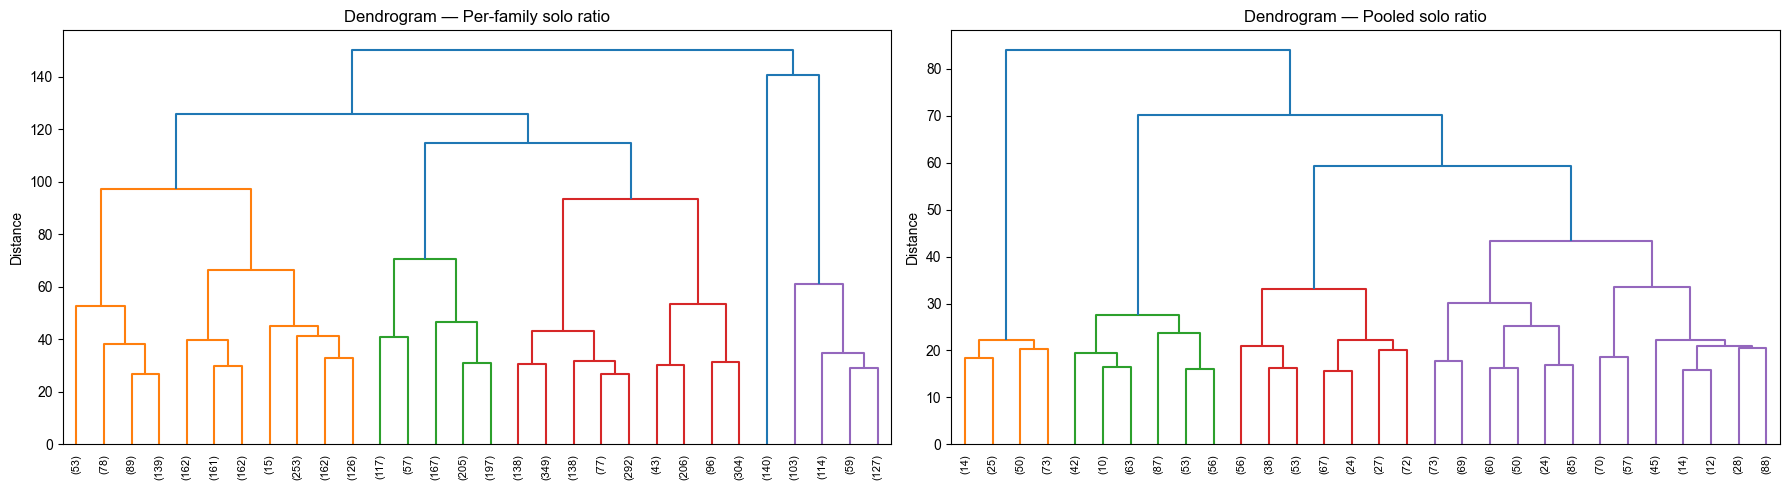

In [39]:
Z_fam  = linkage(squareform(dist_fam),  method='ward')
Z_pool = linkage(squareform(dist_pool), method='ward')

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, label, Z, out_dir in [
    (axes[0], "Per-family", Z_fam,  OUTPUT_DIR_FAM),
    (axes[1], "Pooled",     Z_pool, OUTPUT_DIR_POOL),
]:
    dendrogram(Z, truncate_mode='lastp', p=30, ax=ax, leaf_rotation=90, leaf_font_size=8)
    ax.set_title(f'Dendrogram — {label} solo ratio')
    ax.set_ylabel('Distance')
    plt.savefig(os.path.join(out_dir, 'dtw_dendrogram.svg'), dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

## Step 4: Assign clusters

Set `K_FAM` and `K_POOL` after inspecting the dendrograms above.

In [48]:
# --- SET K after inspecting dendrograms ---
K_FAM  = 2
K_POOL = 2

meta_fam['cluster']  = fcluster(Z_fam,  t=K_FAM,  criterion='maxclust')
meta_pool['cluster'] = fcluster(Z_pool, t=K_POOL, criterion='maxclust')

print("Per-family sizes:"); print(meta_fam['cluster'].value_counts().sort_index())
print("\nPooled sizes:");    print(meta_pool['cluster'].value_counts().sort_index())

Per-family sizes:
cluster
1    3786
2     543
Name: count, dtype: int64

Pooled sizes:
cluster
1     162
2    1323
Name: count, dtype: int64


In [49]:
# --- EDIT LABELS after inspecting centroid plots below ---
CLUSTER_LABELS_FAM  = {i+1: f'Cluster {i+1}' for i in range(K_FAM)}
CLUSTER_LABELS_POOL = {i+1: f'Cluster {i+1}' for i in range(K_POOL)}

# Example labels (adjust once you've seen the centroid profiles):
#CLUSTER_LABELS_POOL = {1: 'Distal removal', 2: 'Uniform removal'}

## Step 5: Plot cluster centroid profiles

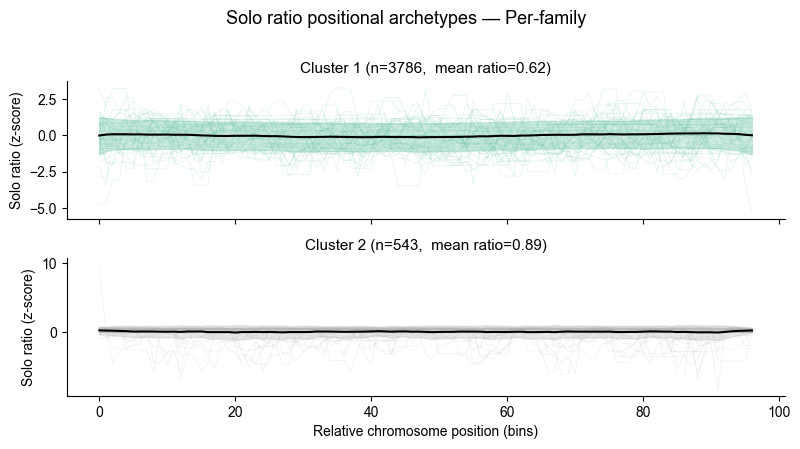

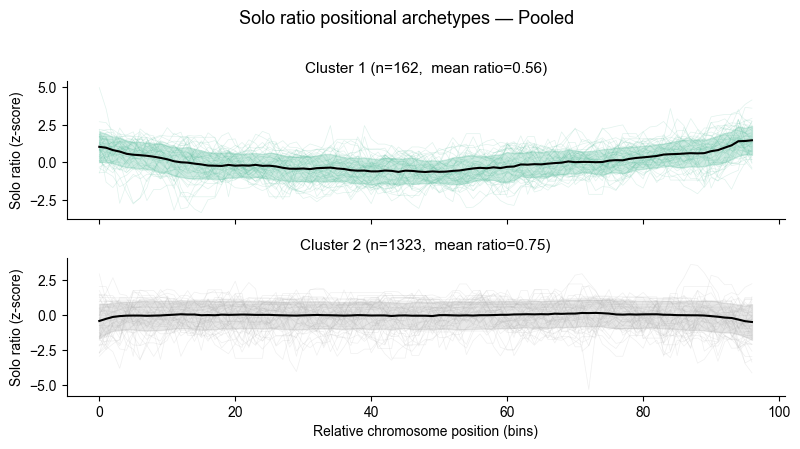

In [50]:
bins_x = np.arange(V_fam.shape[1])
ylabel = 'Solo ratio (z-score)' if ZSCORE else 'Solo ratio'

for label, V, meta, K, CLUSTER_LABELS, out_dir in [
    ("Per-family", V_fam,  meta_fam,  K_FAM,  CLUSTER_LABELS_FAM,  OUTPUT_DIR_FAM),
    ("Pooled",     V_pool, meta_pool, K_POOL, CLUSTER_LABELS_POOL, OUTPUT_DIR_POOL),
]:
    colors = plt.get_cmap('Set2')(np.linspace(0, 1, K))
    fig, axes = plt.subplots(K, 1, figsize=(8, 2.2 * K), sharex=True)
    if K == 1: axes = [axes]

    for i, ax in enumerate(axes):
        cluster_id = i + 1
        mask = meta['cluster'] == cluster_id
        cp = V[mask]

        step = max(1, len(cp) // 50)
        for prof in cp[::step]:
            ax.plot(bins_x, prof, color=colors[i], alpha=0.2, lw=0.5)

        mean_prof = cp.mean(axis=0)
        std_prof  = cp.std(axis=0)
        ax.fill_between(bins_x, mean_prof - std_prof, mean_prof + std_prof,
                        color=colors[i], alpha=0.3)
        ax.plot(bins_x, mean_prof, color='black', lw=1.5)

        # Annotate with mean absolute solo ratio for context
        mean_abs = meta.loc[mask, 'mean_ratio'].mean()
        ax.set_ylabel(ylabel)
        ax.set_title(f'{CLUSTER_LABELS[cluster_id]} (n={mask.sum()},  mean ratio={mean_abs:.2f})',
                     fontsize=11)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    axes[-1].set_xlabel('Relative chromosome position (bins)')
    fig.suptitle(f'Solo ratio positional archetypes — {label}', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, 'dtw_cluster_profiles.svg'), dpi=300, bbox_inches='tight')
    plt.show()

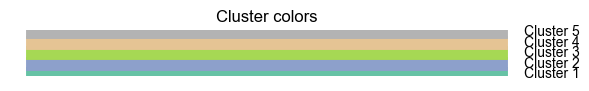

In [43]:
# view color palette
colors = plt.get_cmap('Set2')(np.linspace(0, 1, 5))
plt.figure(figsize=(6, 1))
for i in range(5):
    plt.plot([0, 1], [i, i], color=colors[i], lw=10)
    plt.text(1.05, i, f'Cluster {i+1}', va='center', fontsize=10)
plt.axis('off')
plt.title('Cluster colors', fontsize=12)
plt.tight_layout()
plt.show()

## Step 6: Holo vs mono composition per cluster

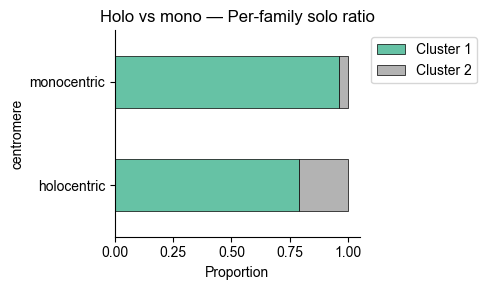

[Per-family] χ²=282.27, df=1, p=0.0000


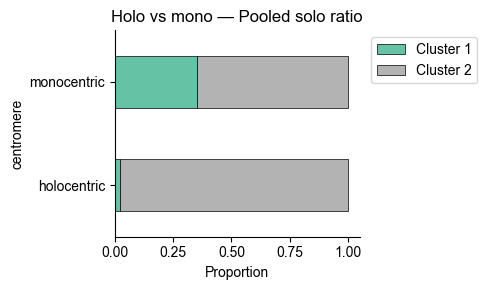

[Pooled] χ²=317.55, df=1, p=0.0000


In [51]:
for label, meta, K, CLUSTER_LABELS, out_dir in [
    ("Per-family", meta_fam,  K_FAM,  CLUSTER_LABELS_FAM,  OUTPUT_DIR_FAM),
    ("Pooled",     meta_pool, K_POOL, CLUSTER_LABELS_POOL, OUTPUT_DIR_POOL),
]:
    colors = plt.get_cmap('Set2')(np.linspace(0, 1, K))
    ct = pd.crosstab(meta['centromere'], meta['cluster'], normalize='index')
    ct.columns = [CLUSTER_LABELS[c] for c in ct.columns]

    fig, ax = plt.subplots(figsize=(5, 3))
    ct.plot(kind='barh', stacked=True, ax=ax, color=colors[:K],
            edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Proportion')
    ax.set_title(f'Holo vs mono — {label} solo ratio')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, 'cluster_holo_vs_mono.svg'), bbox_inches='tight')
    plt.show()

    ct_raw = pd.crosstab(meta['centromere'], meta['cluster'])
    chi2, p, dof, _ = chi2_contingency(ct_raw)
    print(f"[{label}] χ²={chi2:.2f}, df={dof}, p={p:.4f}")

## Step 7: Cluster composition by TE family (per-family only)

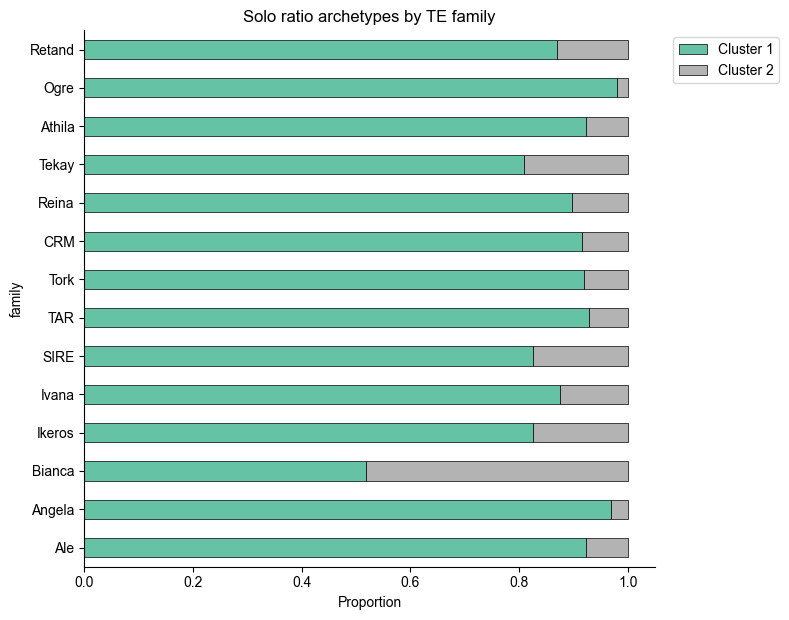

In [45]:
family_order = [f for f in FAMILIES if f in meta_fam['family'].unique()]
colors = plt.get_cmap('Set2')(np.linspace(0, 1, K_FAM))

ct_fam = pd.crosstab(meta_fam['family'], meta_fam['cluster'], normalize='index')
ct_fam.columns = [CLUSTER_LABELS_FAM[c] for c in ct_fam.columns]
ct_fam = ct_fam.reindex(family_order)

fig, ax = plt.subplots(figsize=(8, max(4, len(ct_fam) * 0.45)))
ct_fam.plot(kind='barh', stacked=True, ax=ax, color=colors[:K_FAM],
            edgecolor='black', linewidth=0.5)
ax.set_xlabel('Proportion'); ax.set_title('Solo ratio archetypes by TE family')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_FAM, 'cluster_by_family.svg'), bbox_inches='tight')
plt.show()

## Step 8: Family × centromere type

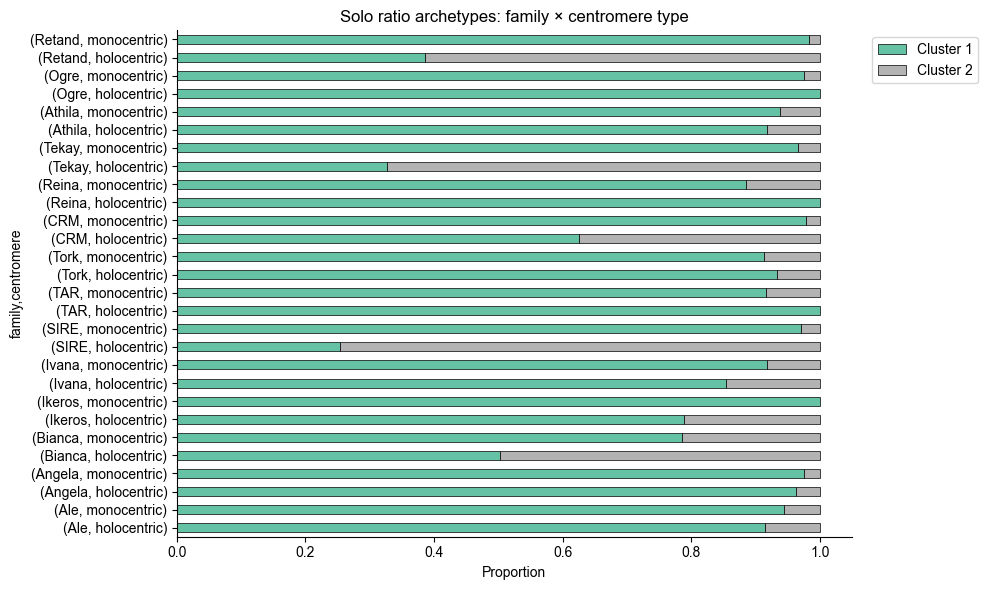

In [46]:
ct_fc = pd.crosstab([meta_fam['family'], meta_fam['centromere']],
                    meta_fam['cluster'], normalize='index')
ct_fc.columns = [CLUSTER_LABELS_FAM[c] for c in ct_fc.columns]

desired_order = [(f, ct) for f in family_order
                 for ct in ['holocentric', 'monocentric']
                 if (f, ct) in ct_fc.index]
ct_fc = ct_fc.reindex(desired_order)

colors = plt.get_cmap('Set2')(np.linspace(0, 1, K_FAM))
fig, ax = plt.subplots(figsize=(max(10, len(ct_fc) * 0.35), 6))
ct_fc.plot(kind='barh', stacked=True, ax=ax, color=colors[:K_FAM],
           edgecolor='black', linewidth=0.5)
ax.set_xlabel('Proportion'); ax.set_title('Solo ratio archetypes: family × centromere type')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_FAM, 'cluster_family_x_centromere.svg'), bbox_inches='tight')
plt.show()

## Step 9: Per-species stacked bar

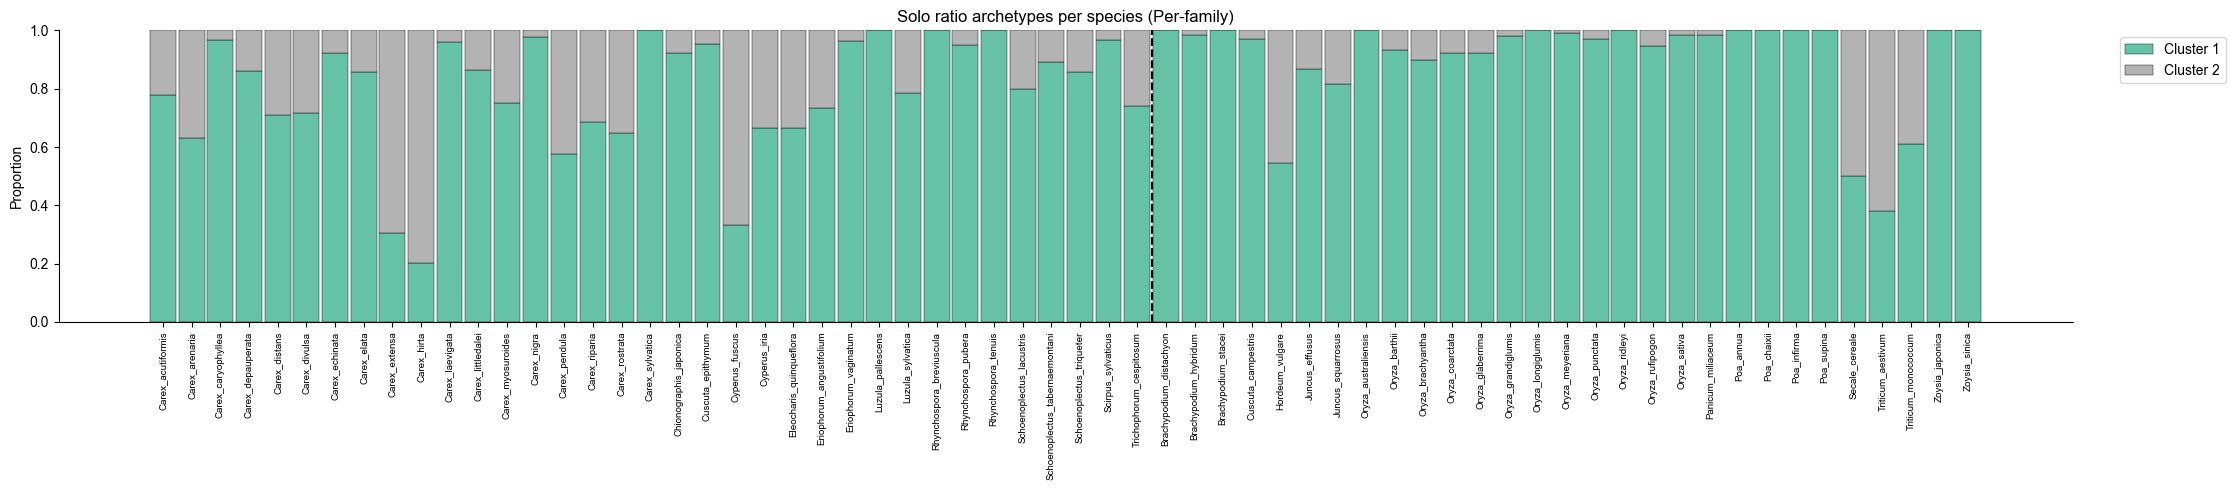

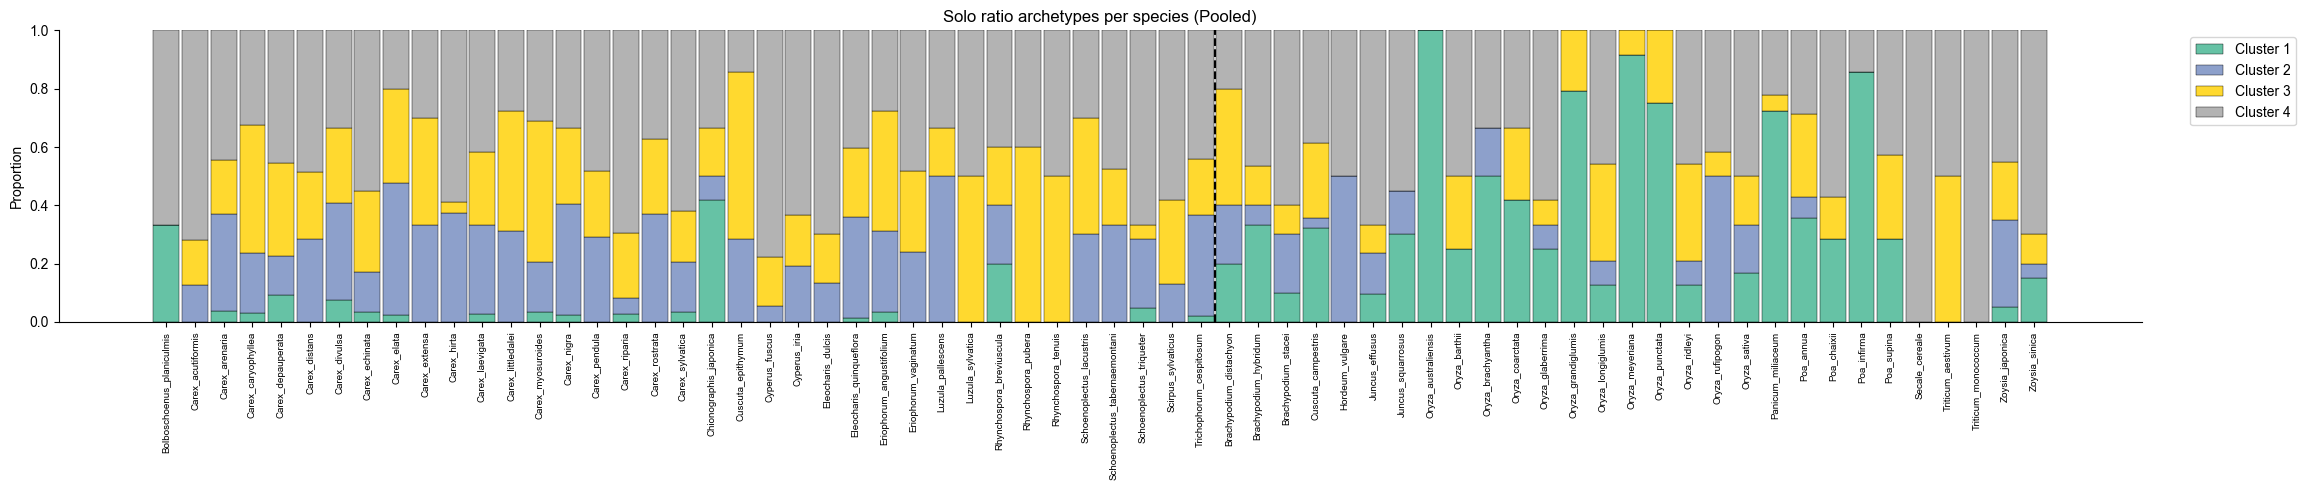

In [47]:
for label, meta, K, CLUSTER_LABELS, out_dir in [
    ("Per-family", meta_fam,  K_FAM,  CLUSTER_LABELS_FAM,  OUTPUT_DIR_FAM),
    ("Pooled",     meta_pool, K_POOL, CLUSTER_LABELS_POOL, OUTPUT_DIR_POOL),
]:
    colors = plt.get_cmap('Set2')(np.linspace(0, 1, K))
    ct_sp = pd.crosstab(meta['species'], meta['cluster'], normalize='index')
    ct_sp.columns = [CLUSTER_LABELS[c] for c in ct_sp.columns]
    ct_sp['centromere'] = ct_sp.index.map(CENTROMERE_TYPE)
    ct_sp = ct_sp.sort_values(['centromere', 'species'], ascending=[True, True])
    centromere_col = ct_sp.pop('centromere')

    fig, ax = plt.subplots(figsize=(max(12, len(ct_sp) * 0.35), 5))
    x = np.arange(len(ct_sp)); bottom = np.zeros(len(ct_sp))
    for j, col in enumerate(ct_sp.columns):
        ax.bar(x, ct_sp[col].values, bottom=bottom, color=colors[j],
               label=col, edgecolor='black', linewidth=0.3, width=0.9)
        bottom += ct_sp[col].values

    ax.set_xticks(x)
    ax.set_xticklabels(ct_sp.index, rotation=90, fontsize=7)
    ax.set_ylabel('Proportion')
    ax.set_title(f'Solo ratio archetypes per species ({label})')

    n_holo = (centromere_col == 'holocentric').sum()
    if 0 < n_holo < len(ct_sp):
        ax.axvline(n_holo - 0.5, color='black', lw=1.5, ls='--')

    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, 'cluster_per_species.svg'), bbox_inches='tight')
    plt.show()